In [94]:
import pandas as pd
import numpy as np
import sklearn
from sklearn import linear_model
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as pyplot
from matplotlib import style
from scipy.stats import zscore

In [112]:
# Read and load data 
data = pd.read_csv("data.csv")
# This is the attributes that will be used
#[["date", "price", "bedrooms", "bathrooms", "sqft_living", "sqft_lot", "floors", "waterfront", "view", "sqft_above", "sqft_basement", "yr_built", "yr_renovated", "street", "city", "statezip", "country"]]
data = data[["price", "bedrooms", "bathrooms", "sqft_living", "sqft_lot", "floors"]]
# clean the data by removing houses with 0 cost
data_cleaned = data[data["price"] != 0]
# check the data 
data.head()

,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors
0,313000.0,3.0,1.50,1340,7912,1.5
1,2384000.0,5.0,2.50,3650,9050,2.0
2,342000.0,3.0,2.00,1930,11947,1.0
3,420000.0,3.0,2.25,2000,8030,1.0
4,550000.0,4.0,2.50,1940,10500,1.0


In [118]:
# normalise sqft_living with zscore
data_cleaned["sqft_living_zscore"] = zscore(data_cleaned["sqft_living"])

data_cleaned["sqft_lot_zscore"] = zscore(data_cleaned["sqft_lot"])
# This is the feature that will be predicted
predict = "price"
# create a new array after removing "price" so that it can be predicted
x = np.array(np.delete(data_cleaned, (0,3,4), axis=1))
y = np.array(data_cleaned[predict])

print(data_cleaned.head())
print(x)
print(y)

       price  bedrooms  bathrooms  sqft_living  sqft_lot  floors  \
0   313000.0       3.0       1.50         1340      7912     1.5   
1  2384000.0       5.0       2.50         3650      9050     2.0   
2   342000.0       3.0       2.00         1930     11947     1.0   
3   420000.0       3.0       2.25         2000      8030     1.0   
4   550000.0       4.0       2.50         1940     10500     1.0   

   sqft_living_zscore  sqft_lot_zscore  
0           -0.828976        -0.192527  
1            1.587735        -0.160880  
2           -0.211721        -0.080319  
3           -0.138487        -0.189245  
4           -0.201259        -0.120558  
[[ 3.          1.5         1.5        -0.82897593 -0.19252659]
 [ 5.          2.5         2.          1.58773472 -0.16088043]
 [ 3.          2.          1.         -0.21172083 -0.08031898]
 ...
 [ 3.          2.5         2.          0.91816986 -0.2174987 ]
 [ 4.          2.          1.         -0.04432961 -0.22817719]
 [ 3.          2.5       

In [119]:
best_score = 0
for _ in range(10000):
    # split into training and testing sets
    x_train, x_test, y_train, y_test = sklearn.model_selection.train_test_split(x, y, test_size=0.01)
    # creates a linear model
    linear = linear_model.LinearRegression()
    # fit the data to a linear model
    linear.fit(x_train, y_train)
    # check the accuracy of the model
    accuracy = linear.score(x_test, y_test)
    # checks for the best score
    if accuracy > best_score:
        best_score = accuracy

print(best_score)

0.8497797568767194


In [122]:
# take x_test (unused) array and predict "price" results
predictions = linear.predict(x_test)
print(predictions)

for val in range(len(predictions)):
    # displays the predicted results, "x_test" input, and the actual result output from "y_test"
    print(predictions[val], x_test[val], y_test[val])

[ 450399.91924167  669590.54598313  414318.9887894   406867.2385372
  684214.1594123   921674.38985183  501375.34754688  751434.73523119
  650916.94786744  825186.00647494  435131.80981888  580470.31208612
  404585.63509475  681451.21111224  385996.8110092   391516.01485182
  522085.00272546  295369.38304898  475541.03230307  532930.02441237
  692288.43605879  273137.04195636  437909.84258912  466611.43704547
  486848.72033418 1107794.77343605  656677.07181861  833217.32351629
  550999.0809328   534864.22907501  552623.96511864  390288.35431632
  303571.09163557  755441.20519423  491911.86590896  528616.03083063
  752576.96080599  394541.39170185  652551.99546383 1234719.0814592
 1163073.76289725 1197518.74927857 1366278.13260237  421433.7035491
  468339.91139905  347058.41842932]
450399.9192416707 [ 3.          2.25        2.         -0.48373155 -0.36816557] 505000.0
669590.5459831294 [ 4.          3.25        1.5         0.40553427 -0.31911124] 618250.0
414318.98878940113 [ 3.       

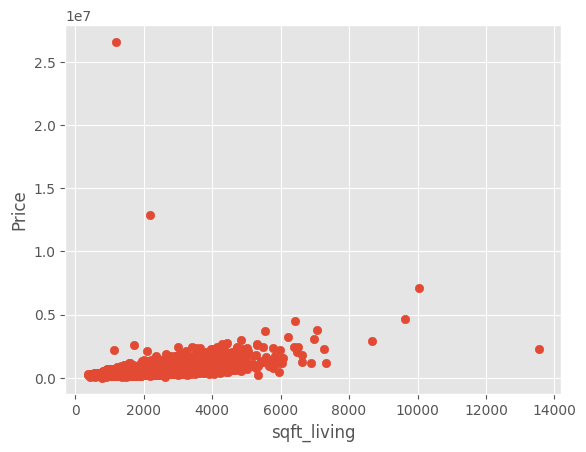

In [121]:
# print results on a graph
x_info = "sqft_living"
style.use("ggplot")
pyplot.scatter(data_cleaned[x_info], data_cleaned["price"])
pyplot.xlabel(x_info)
pyplot.ylabel("Price")
pyplot.show()